# Pre-application distribution × permit volume comparison

Six scenarios: `lognormal_10`, `lognormal_60`, and `lognormal_180` pre-application distributions, each run with **2,000** and **6,500** permits.

**Outputs**
- Summary table: mean **disaster → ready for construction** and **plan application → ready for construction** (pooled across permits, plus run-level uncertainty).
- **2×3 grid**: average waiting vs service time by process step (permits pooled across Monte Carlo runs per scenario).
- **2×3 grid**: mean staff utilization over time (average across runs).

Reduce `N_RUNS` for a quick smoke test; increase for smoother Monte Carlo means.


In [1]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import run_simulation
importlib.reload(run_simulation)
from run_simulation import run_multiple_simulations, plot_staff_utilization_series

import visualize_permits
importlib.reload(visualize_permits)
from visualize_permits import plot_average_waiting_and_service_by_step

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

# --- Monte Carlo & shared staffing (match your main baseline unless you edit) ---
N_RUNS = 20
BASE_SEED = 42
SEQUENTIAL_MODE = "standard"
PERMIT_MIX = "balanced"
SIMULATION_DURATION = None
UTILIZATION_STEP = 0.05

PRE_APPLICATION_DISTS = ["lognormal_10", "lognormal_60", "lognormal_180"]
PERMIT_COUNTS = [2000, 6500]

SHARED_SCENARIO_KNOBS = {
    "sequential": SEQUENTIAL_MODE,
    "ai_review": "none",
    "permit_mix": PERMIT_MIX,
    "review_duration_families": None,
    "review_duration_multipliers": None,
    "planning_staff_count": 20,
    "planning_caseload_per_staff": 7,
    "public_works_staff_count": 30,
    "public_works_caseload_per_staff": 7,
    "fire_staff_count": 10,
    "fire_caseload_per_staff": 7,
}


def scenario_key(dist: str, n: int) -> str:
    return f"{dist} | n={n:,}"


def row_col_for(n_permits: int, dist: str):
    row = PERMIT_COUNTS.index(n_permits)
    col = PRE_APPLICATION_DISTS.index(dist)
    return row, col


# Explicit scenario order: rows = permit count, cols = distribution
SCENARIO_PARAMS_LIST = []
for n in PERMIT_COUNTS:
    for dist in PRE_APPLICATION_DISTS:
        SCENARIO_PARAMS_LIST.append(
            {
                "name": scenario_key(dist, n),
                "num_permits": n,
                "pre_application_distribution": dist,
                **SHARED_SCENARIO_KNOBS,
            }
        )

n_tasks = len(SCENARIO_PARAMS_LIST) * N_RUNS
print(f"Total simulation runs: {n_tasks} ({len(SCENARIO_PARAMS_LIST)} scenarios × {N_RUNS} runs)")


Total simulation runs: 120 (6 scenarios × 20 runs)


In [2]:
results, average_staff_util_by_scenario = run_multiple_simulations(
    n_runs=N_RUNS,
    num_permits=6500,
    simulation_duration=SIMULATION_DURATION,
    base_seed=BASE_SEED,
    scenario_params_list=SCENARIO_PARAMS_LIST,
    collect_permits=True,
    collect_average_staff_utilization=True,
    utilization_step=UTILIZATION_STEP,
)

permits_by_scenario = {}
for entry in results:
    permits_by_scenario.setdefault(entry["scenario"], []).extend(entry.get("permits", []))

print("Completed. Permits collected per scenario:")
for scenario_def in SCENARIO_PARAMS_LIST:
    name = scenario_def["name"]
    n_expect = scenario_def["num_permits"]
    plist = permits_by_scenario.get(name, [])
    print(f"  {name}: {len(plist):,} permits (expected {N_RUNS * n_expect:,})")


Completed. Permits collected per scenario:
  lognormal_10 | n=2,000: 40,000 permits (expected 40,000)
  lognormal_60 | n=2,000: 40,000 permits (expected 40,000)
  lognormal_180 | n=2,000: 40,000 permits (expected 40,000)
  lognormal_10 | n=6,500: 130,000 permits (expected 130,000)
  lognormal_60 | n=6,500: 130,000 permits (expected 130,000)
  lognormal_180 | n=6,500: 130,000 permits (expected 130,000)


In [3]:
def disaster_to_ready_days(p):
    if p.ready_for_construction is None or p.created_at is None:
        return None
    return float(p.ready_for_construction - p.created_at)


def application_to_ready_days(p):
    if p.ready_for_construction is None or p.planning_request is None:
        return None
    return float(p.ready_for_construction - p.planning_request)


rows = []
for scenario_def in SCENARIO_PARAMS_LIST:
    scenario_name = scenario_def["name"]
    perms = permits_by_scenario.get(scenario_name, [])
    dvals = [disaster_to_ready_days(p) for p in perms]
    avals = [application_to_ready_days(p) for p in perms]
    dvals = [x for x in dvals if x is not None]
    avals = [x for x in avals if x is not None]

    run_disaster_means = []
    run_app_means = []
    for entry in results:
        if entry["scenario"] != scenario_name:
            continue
        rp = entry.get("permits", [])
        rd = [disaster_to_ready_days(p) for p in rp]
        ra = [application_to_ready_days(p) for p in rp]
        rd = [x for x in rd if x is not None]
        ra = [x for x in ra if x is not None]
        if rd:
            run_disaster_means.append(float(np.mean(rd)))
        if ra:
            run_app_means.append(float(np.mean(ra)))

    rows.append(
        {
            "pre_application_distribution": scenario_def["pre_application_distribution"],
            "num_permits": scenario_def["num_permits"],
            "pooled_mean_disaster_to_ready_days": float(np.mean(dvals)) if dvals else np.nan,
            "pooled_mean_application_to_ready_days": float(np.mean(avals)) if avals else np.nan,
            "run_mean_disaster_to_ready_mean": float(np.mean(run_disaster_means)) if run_disaster_means else np.nan,
            "run_mean_disaster_to_ready_std": float(np.std(run_disaster_means, ddof=1)) if len(run_disaster_means) > 1 else 0.0,
            "run_mean_application_to_ready_mean": float(np.mean(run_app_means)) if run_app_means else np.nan,
            "run_mean_application_to_ready_std": float(np.std(run_app_means, ddof=1)) if len(run_app_means) > 1 else 0.0,
            "n_permits_pooled": len(dvals),
        }
    )

metrics_df = pd.DataFrame(rows)
metrics_df = metrics_df.sort_values(["num_permits", "pre_application_distribution"]).reset_index(drop=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
metrics_df


,pre_application_distribution,num_permits,pooled_mean_disaster_to_ready_days,pooled_mean_application_to_ready_days,run_mean_disaster_to_ready_mean,run_mean_disaster_to_ready_std,run_mean_application_to_ready_mean,run_mean_application_to_ready_std,n_permits_pooled
0,lognormal_10,2000,174.851504,166.214260,174.851504,1.385552,166.214260,1.400225,40000
1,lognormal_180,2000,276.463190,120.992792,276.463190,2.430880,120.992792,1.228126,40000
2,lognormal_60,2000,182.560305,130.736839,182.560305,1.581553,130.736839,1.665812,40000
3,lognormal_10,6500,326.694578,318.036133,326.694578,1.989302,318.036133,1.973735,130000
4,lognormal_180,6500,365.261262,209.409258,365.261262,2.687349,209.409258,2.460219,130000
5,lognormal_60,6500,320.801924,268.851256,320.801924,1.503203,268.851256,1.681068,130000


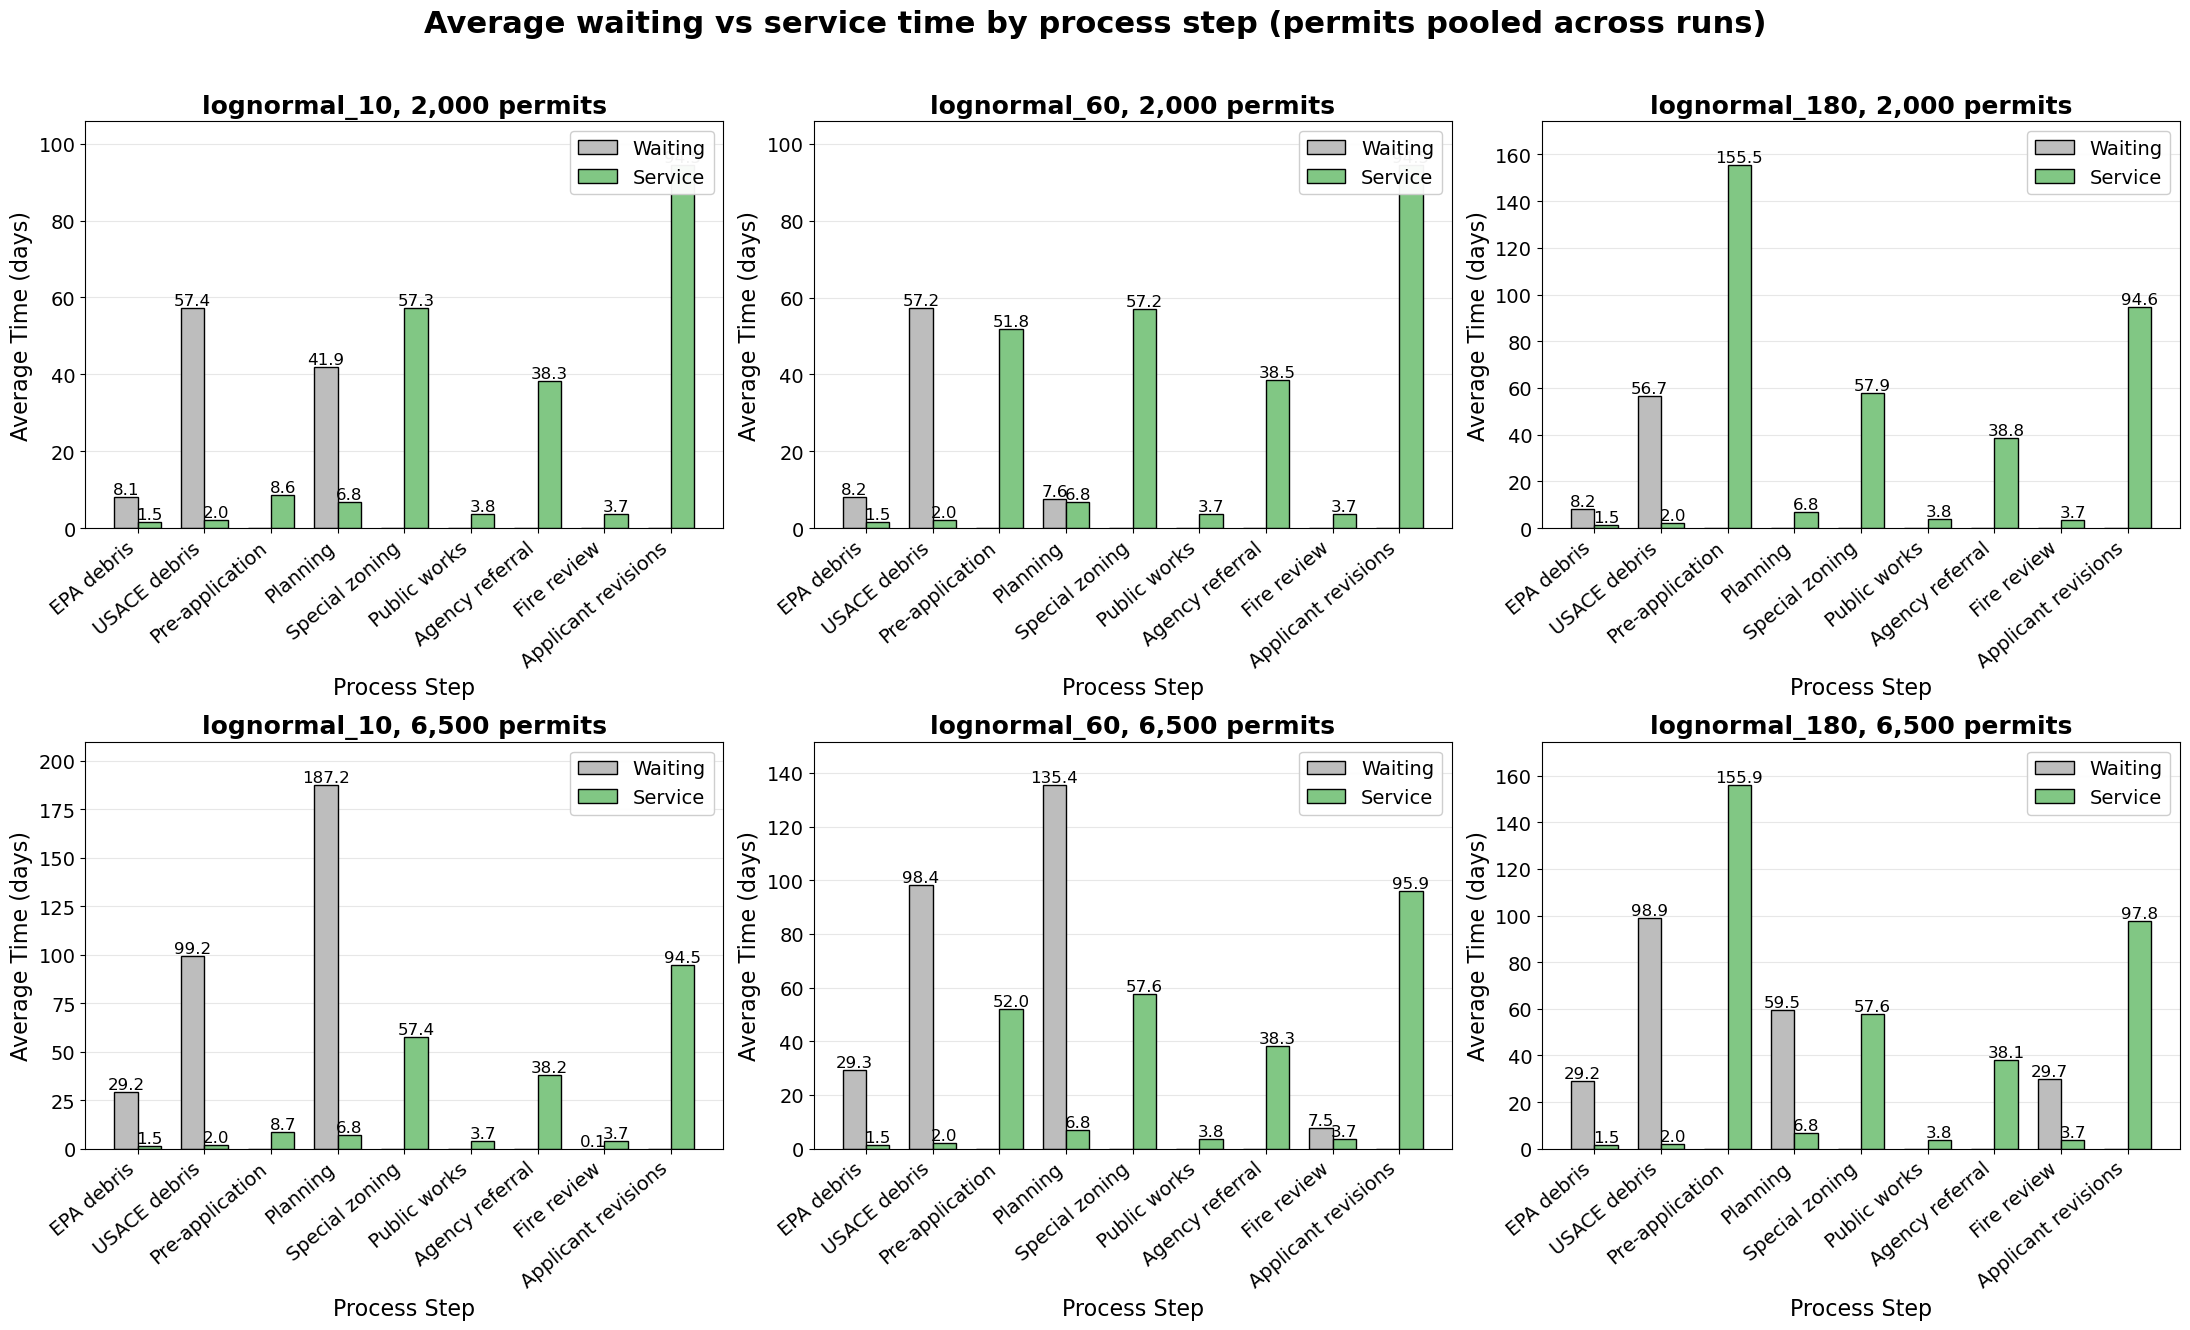

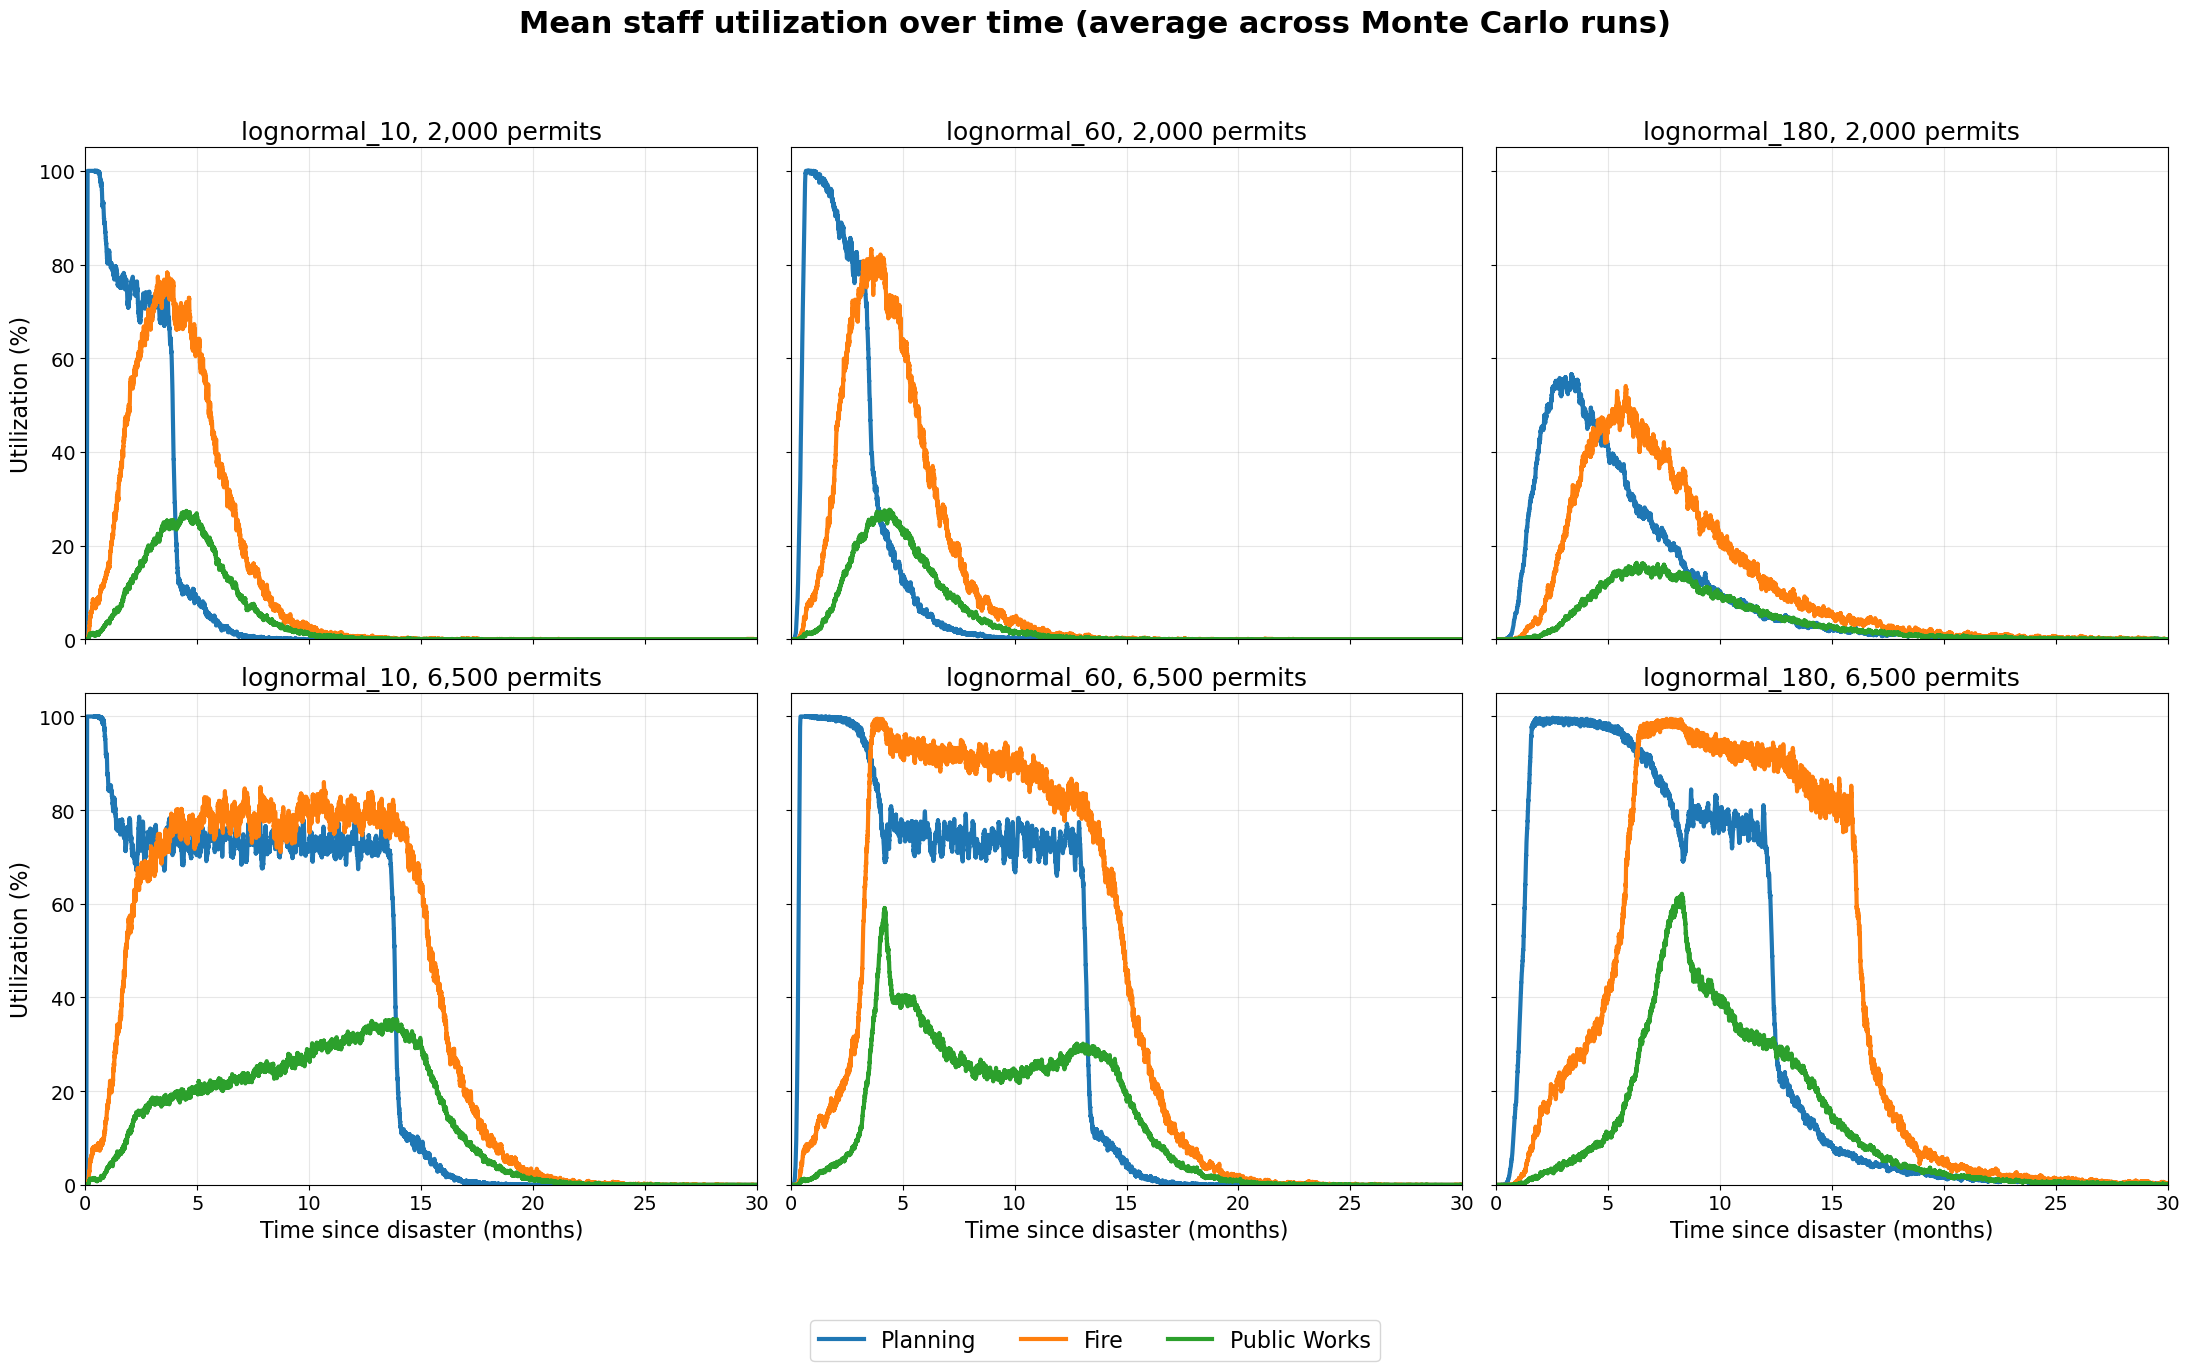

In [11]:
# Optional: save metrics for thesis tables
# metrics_df.to_csv("preapp_volume_scenario_metrics.csv", index=False)

import importlib

import run_simulation

importlib.reload(run_simulation)

from run_simulation import plot_staff_utilization_series

import visualize_permits

importlib.reload(visualize_permits)

from visualize_permits import plot_average_waiting_and_service_by_step

label_map = {
    "EPA Debris": "EPA debris",
    "USACE Debris": "USACE debris",
    "Pre-Application Activities": "Pre-application",
    "Planning": "Planning",
    "Special Zoning": "Special zoning",
    "Public Works": "Public works",
    "Agency Referral": "Agency referral",
    "Fire Review": "Fire review",
    "Applicant Revisions": "Applicant revisions",
}

# Thesis-scale typography (matplotlib pt)
FIG_SUPTITLE = 22
PANEL_TITLE = 18
PANEL_AXIS = 16
PANEL_TICK = 14
PANEL_LEGEND = 14
BAR_VALUES = 12
UTIL_LINE_WIDTH = 3.0
FIG_LEGEND = 16

fig_w, axes_w = plt.subplots(2, 3, figsize=(22, 13), sharey=False)
fig_w.suptitle(
    "Average waiting vs service time by process step (permits pooled across runs)",
    fontsize=FIG_SUPTITLE,
    fontweight="bold",
    y=1.02,
)

for n in PERMIT_COUNTS:
    for dist in PRE_APPLICATION_DISTS:
        sname = scenario_key(dist, n)
        row, col = row_col_for(n, dist)
        ax = axes_w[row, col]
        plist = permits_by_scenario.get(sname, [])
        plot_average_waiting_and_service_by_step(
            plist,
            label_map=label_map,
            ax=ax,
            title=f"{dist}, {n:,} permits",
            silent=True,
            title_size=PANEL_TITLE,
            axis_label_size=PANEL_AXIS,
            tick_label_size=PANEL_TICK,
            legend_size=PANEL_LEGEND,
            bar_value_size=BAR_VALUES,
        )

plt.tight_layout()
plt.show()

fig_u, axes_u = plt.subplots(2, 3, figsize=(22, 13), sharex=True, sharey=True)
fig_u.suptitle(
    "Mean staff utilization over time (average across Monte Carlo runs)",
    fontsize=FIG_SUPTITLE,
    fontweight="bold",
    y=1.02,
)

for n in PERMIT_COUNTS:
    for dist in PRE_APPLICATION_DISTS:
        sname = scenario_key(dist, n)
        row, col = row_col_for(n, dist)
        ax = axes_u[row, col]
        util = average_staff_util_by_scenario[sname]
        plot_staff_utilization_series(
            util,
            title=f"{dist}, {n:,} permits",
            ax=ax,
            legend=False,
            xlim=(0, 30),
            title_size=PANEL_TITLE,
            axis_label_size=PANEL_AXIS,
            tick_label_size=PANEL_TICK,
            line_width=UTIL_LINE_WIDTH,
        )
        if row == 0:
            ax.set_xlabel("")
        if col > 0:
            ax.set_ylabel("")

handles, labels = axes_u[0, 0].get_legend_handles_labels()
fig_u.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 0.02),
    fontsize=FIG_LEGEND,
)

plt.tight_layout(rect=(0, 0.06, 1, 0.98))
plt.show()
